In [130]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Exp1.Exp1 import perform_eda

Dataset: Spam Email Classification
Shape: (4601, 58)
------------------------------------------------------------
Column Types:
word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float6

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


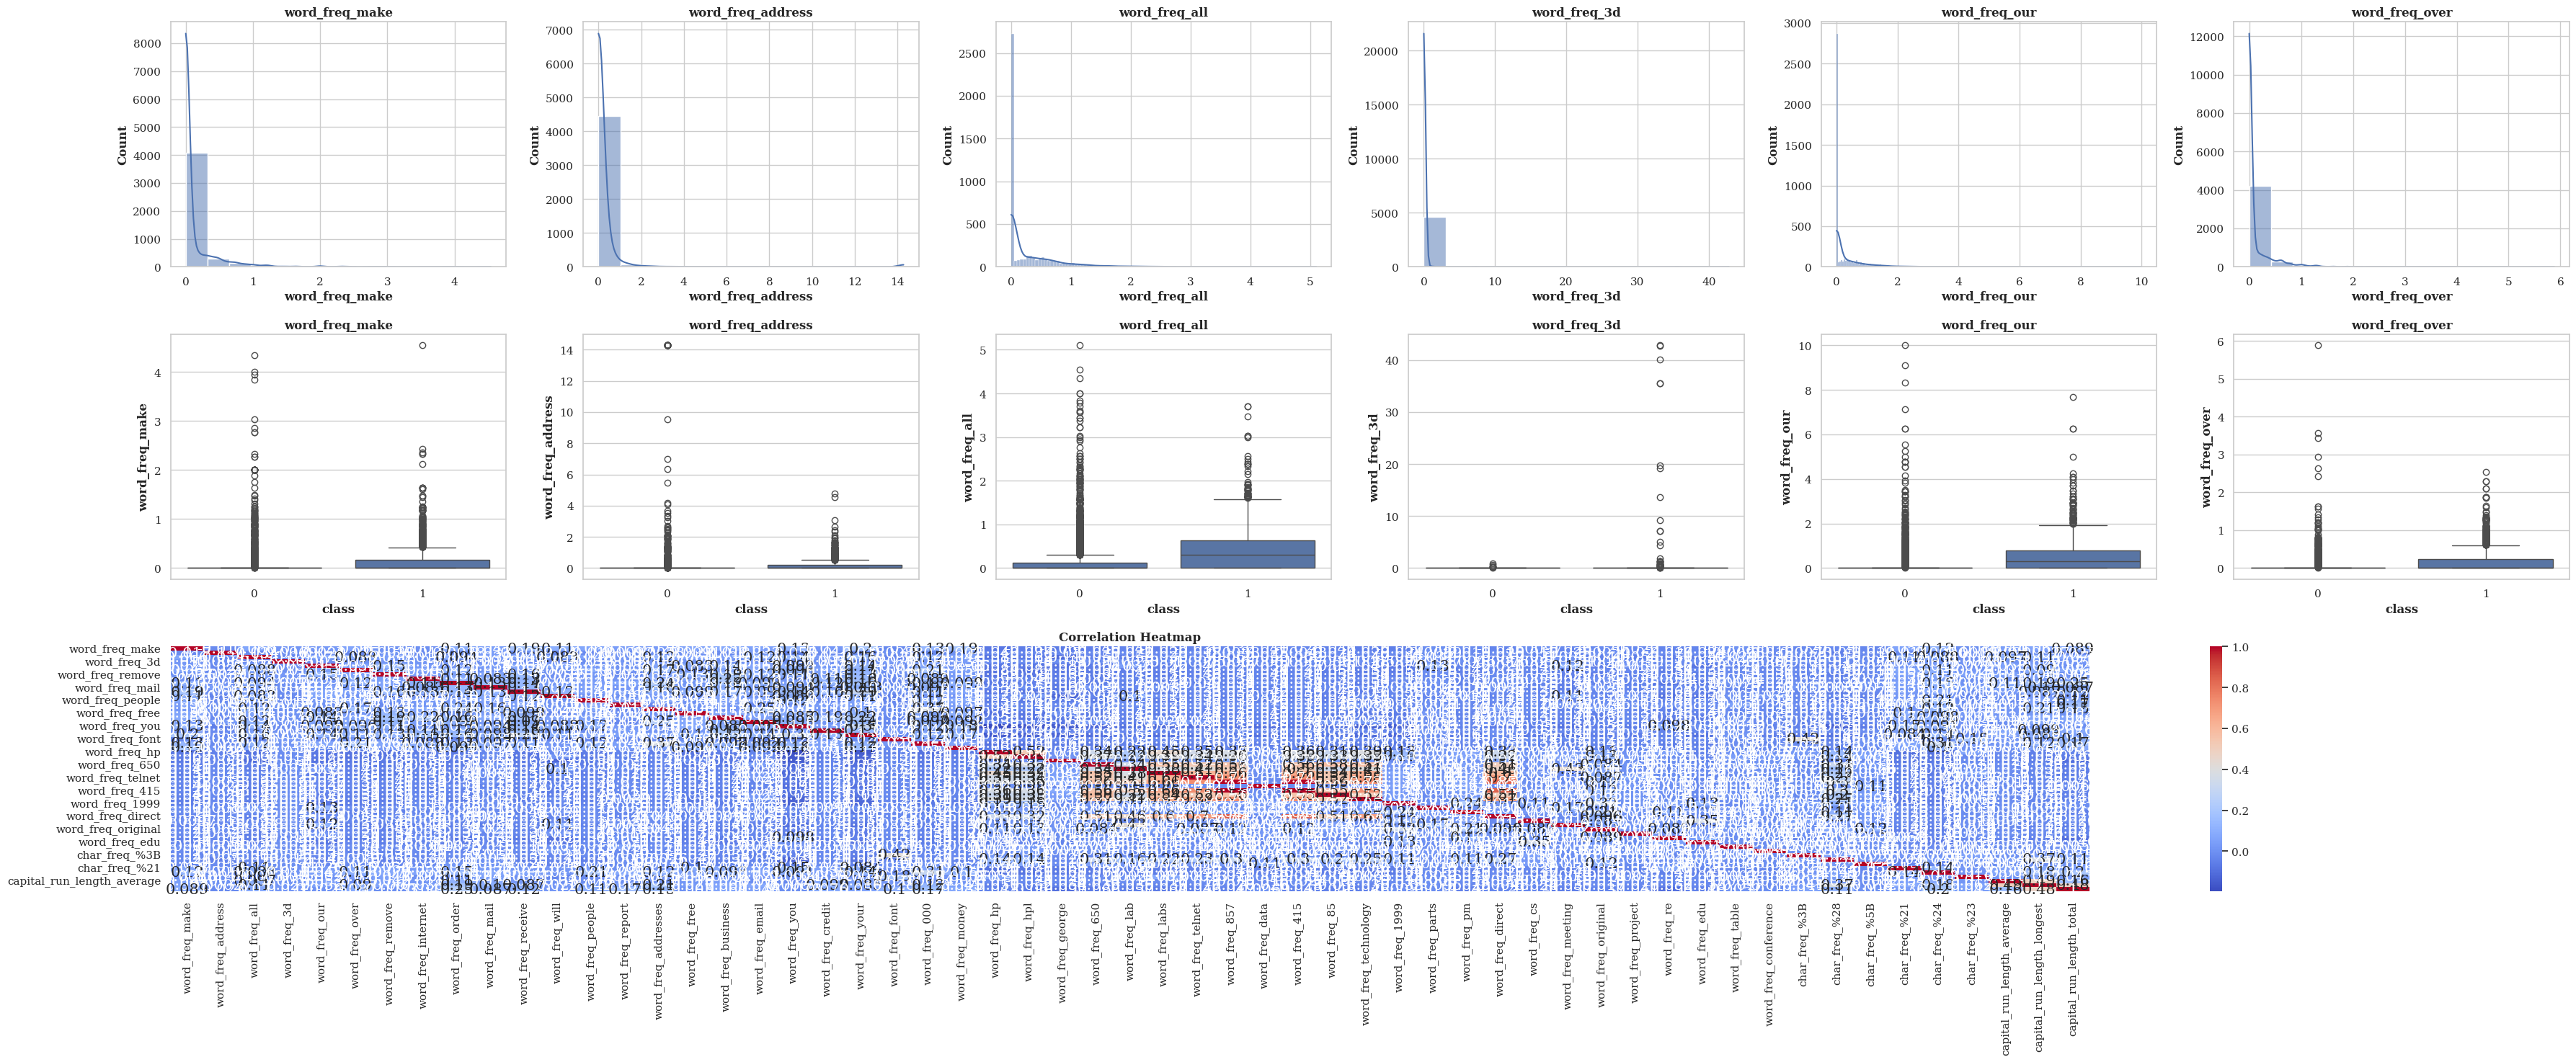

word_freq_make
Mean: 0.10455335796565964
Median: 0.0
Std Dev: 0.3053575620234699
Min: 0.0
Max: 4.54
Q1: 0.0
Q3: 0.0
Skewness: 5.675639163765851
Kurtosis: 49.30506415870118

word_freq_address
Mean: 0.21301456205172786
Median: 0.0
Std Dev: 1.2905751909453214
Min: 0.0
Max: 14.28
Q1: 0.0
Q3: 0.0
Skewness: 10.086810872543571
Kurtosis: 105.64747160937861

word_freq_all
Mean: 0.28065637904803303
Median: 0.0
Std Dev: 0.5041428838471842
Min: 0.0
Max: 5.1
Q1: 0.0
Q3: 0.42
Skewness: 3.0092485272970904
Kurtosis: 13.308743418467486

word_freq_3d
Mean: 0.06542490762877635
Median: 0.0
Std Dev: 1.3951513704928833
Min: 0.0
Max: 42.81
Q1: 0.0
Q3: 0.0
Skewness: 26.227744470347666
Kurtosis: 726.4515380990603

word_freq_our
Mean: 0.312223429689198
Median: 0.0
Std Dev: 0.672512769284666
Min: 0.0
Max: 10.0
Q1: 0.0
Q3: 0.38
Skewness: 4.747126114133084
Kurtosis: 37.94116889421045

word_freq_over
Mean: 0.09590089111062812
Median: 0.0
Std Dev: 0.2738240830098081
Min: 0.0
Max: 5.88
Q1: 0.0
Q3: 0.0
Skewness: 5.956

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [131]:
# Perform EDA
df = pd.read_csv("spambase_csv.csv")
# print(df['class'])
perform_eda(df, dataset_name="Spam Email Classification")


In [ ]:
# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


y = df['class']
x = df.drop(columns=['class'])

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


In [ ]:
# Multinomial NB Spam Classifier
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(x_train, y_train)
y_pred_mnb = mnb.predict(x_test)

print("Multinomial Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_mnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_mnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_mnb))

Multinomial Naive Bayes Performance:
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       531
           1       0.76      0.72      0.74       390

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921

Confusion Matrix: 
 [[445  86]
 [111 279]]
Accuracy Score:  0.7861020629750272


In [190]:
# Normalizer
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Gaussian NB Spam Classifier
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(x_train, y_train)
y_pred_gnb = gnb.predict(x_test)

print("Gaussian Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_gnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_gnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_gnb))

Gaussian Naive Bayes Performance:
Classification Report:                precision    recall  f1-score   support

           0       0.95      0.73      0.82       531
           1       0.72      0.95      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921

Confusion Matrix:  [[387 144]
 [ 21 369]]
Accuracy Score:  0.8208469055374593


In [192]:
# Bernoulli NB Spam Classifier
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

bnb.fit(x_train, y_train)
y_pred_bnb = bnb.predict(x_test)

print("Bernoulli Naive Bayes Performance:")
print("Classification Report: \n",classification_report(y_test, y_pred_bnb))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred_bnb))
print("Accuracy Score: ", accuracy_score(y_test, y_pred_bnb))

Bernoulli Naive Bayes Performance:
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       531
           1       0.91      0.80      0.85       390

    accuracy                           0.88       921
   macro avg       0.89      0.87      0.88       921
weighted avg       0.88      0.88      0.88       921

Confusion Matrix: 
 [[499  32]
 [ 78 312]]
Accuracy Score:  0.8805646036916395


In [215]:
# KNN Spam Classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("KNearest Neighbors Performance")
print("Classification Report: \n",classification_report(y_pred,y_test))
print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

KNearest Neighbors Performance
Classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.80      0.82       562
           1       0.71      0.77      0.74       359

    accuracy                           0.79       921
   macro avg       0.78      0.79      0.78       921
weighted avg       0.79      0.79      0.79       921

Confusion Matrix: 
 [[450  81]
 [112 278]]
Accuracy Score:  0.7904451682953312


In [217]:
# KNN GridSearchCV Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(x_train_scaled, y_train)


print("--- Tuning Results ---")
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}\n".format(grid_search.best_score_))

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)

print("Best K Value: ",grid_search.best_params_['n_neighbors'])
print("KNN Performance (After Grid Search Tuning)")
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

--- Tuning Results ---
Best Parameters:  {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Accuracy: 0.9255

Best K Value:  11
KNN Performance (After Grid Search Tuning)
Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       531
           1       0.96      0.84      0.89       390

    accuracy                           0.92       921
   macro avg       0.92      0.90      0.91       921
weighted avg       0.92      0.92      0.91       921

Confusion Matrix: 
 [[517  14]
 [ 64 326]]
Accuracy Score:  0.9153094462540716
